# TASK:3

In [1]:

# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [2]:

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
     

Using device: cpu


In [3]:

df = pd.read_csv(r'binary_classification_moons.csv')
df.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


In [4]:

df.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,0.499552,0.249196,0.50000
std,0.867371,0.494822,0.50025
min,-1.061751,-0.571697,0.00000
25%,-0.019860,-0.216408,0.00000
50%,0.502008,0.248686,0.50000
75%,1.020851,0.694288,1.00000
max,2.064637,1.042677,1.00000


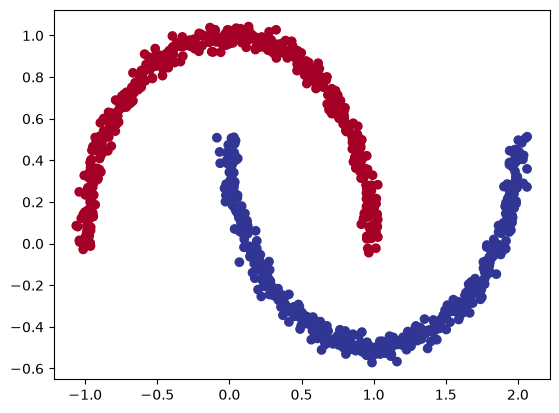

In [5]:

# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=df.X1,
            y=df.X2,
            c=df.label,
            cmap=plt.cm.RdYlBu
            );

In [6]:
# vectorizing X1 and X2 into a single tensor/nparray

X = df[['X1', 'X2']].values
y = df['label'].values

In [7]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [8]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [9]:

# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

C:\Users\bidhi\AppData\Local\Temp\ipykernel_25576\609928622.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [10]:

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [11]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0
     

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [12]:

model = model_0
     

In [13]:

# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.4826],
        [0.1156],
        [0.4274],
        [0.0810],
        [0.2264],
        [0.1663],
        [0.2194],
        [0.2746],
        [0.4704],
        [0.1277]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [14]:

# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)
     

In [15]:

# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits
     

tensor([[0.4826],
        [0.1156],
        [0.4274],
        [0.0810],
        [0.2264]], grad_fn=<SliceBackward0>)

In [16]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6184],
        [0.5289],
        [0.6052],
        [0.5202],
        [0.5564]], grad_fn=<SigmoidBackward0>)

In [17]:

# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()
     

tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.], grad_fn=<SqueezeBackward0>)

In [18]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [19]:

torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
     

In [24]:

from utils import train_and_test_loop
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

Epoch: 0 | Loss: 0.67303, Accuracy: 50.00% | Test loss: 0.65454, Test acc: 50.00%
Epoch: 10 | Loss: 0.54178, Accuracy: 86.12% | Test loss: 0.53955, Test acc: 85.50%
Epoch: 20 | Loss: 0.45195, Accuracy: 84.88% | Test loss: 0.46000, Test acc: 85.00%
Epoch: 30 | Loss: 0.39282, Accuracy: 84.38% | Test loss: 0.40719, Test acc: 85.00%
Epoch: 40 | Loss: 0.35568, Accuracy: 83.62% | Test loss: 0.37321, Test acc: 84.00%
Epoch: 50 | Loss: 0.33208, Accuracy: 83.75% | Test loss: 0.35070, Test acc: 83.50%
Epoch: 60 | Loss: 0.31627, Accuracy: 84.12% | Test loss: 0.33484, Test acc: 83.50%
Epoch: 70 | Loss: 0.30495, Accuracy: 84.62% | Test loss: 0.32285, Test acc: 84.00%
Epoch: 80 | Loss: 0.29631, Accuracy: 84.88% | Test loss: 0.31325, Test acc: 84.50%
Epoch: 90 | Loss: 0.28934, Accuracy: 85.12% | Test loss: 0.30520, Test acc: 85.50%


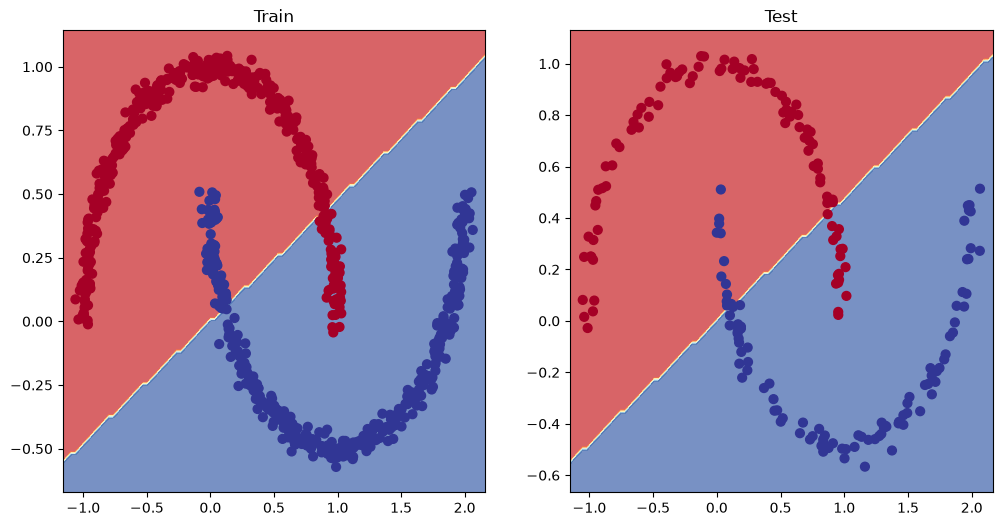

In [25]:
from utils import plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

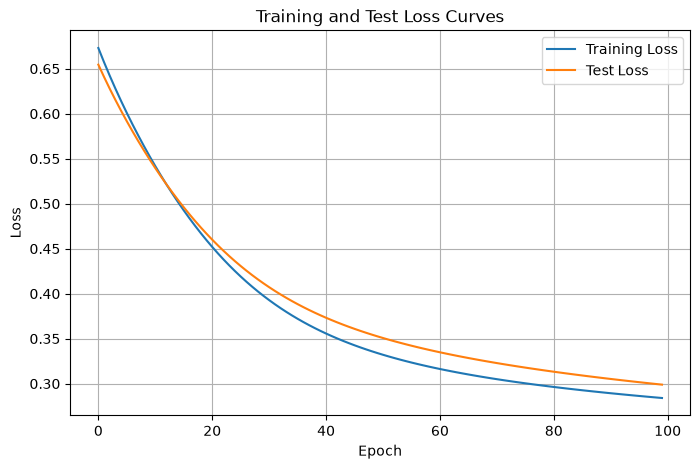

In [26]:

import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

In [27]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = ModelV1().to(device)
model_1
     

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [28]:
model = model_1
epochs = 1000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)
     

Epoch: 0 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.70134, Test acc: 45.50%
Epoch: 10 | Loss: 0.58674, Accuracy: 79.62% | Test loss: 0.58552, Test acc: 78.00%
Epoch: 20 | Loss: 0.47594, Accuracy: 79.62% | Test loss: 0.48700, Test acc: 77.00%
Epoch: 30 | Loss: 0.39832, Accuracy: 81.00% | Test loss: 0.41841, Test acc: 77.00%
Epoch: 40 | Loss: 0.35499, Accuracy: 81.62% | Test loss: 0.37773, Test acc: 78.00%
Epoch: 50 | Loss: 0.32886, Accuracy: 82.62% | Test loss: 0.35055, Test acc: 80.50%
Epoch: 60 | Loss: 0.31010, Accuracy: 83.75% | Test loss: 0.32940, Test acc: 82.00%
Epoch: 70 | Loss: 0.29513, Accuracy: 84.75% | Test loss: 0.31171, Test acc: 83.50%
Epoch: 80 | Loss: 0.28276, Accuracy: 85.00% | Test loss: 0.29670, Test acc: 85.50%
Epoch: 90 | Loss: 0.27260, Accuracy: 85.62% | Test loss: 0.28413, Test acc: 86.50%
Epoch: 100 | Loss: 0.26443, Accuracy: 86.25% | Test loss: 0.27384, Test acc: 87.50%
Epoch: 110 | Loss: 0.25803, Accuracy: 87.00% | Test loss: 0.26561, Test acc: 87.50%
Epo

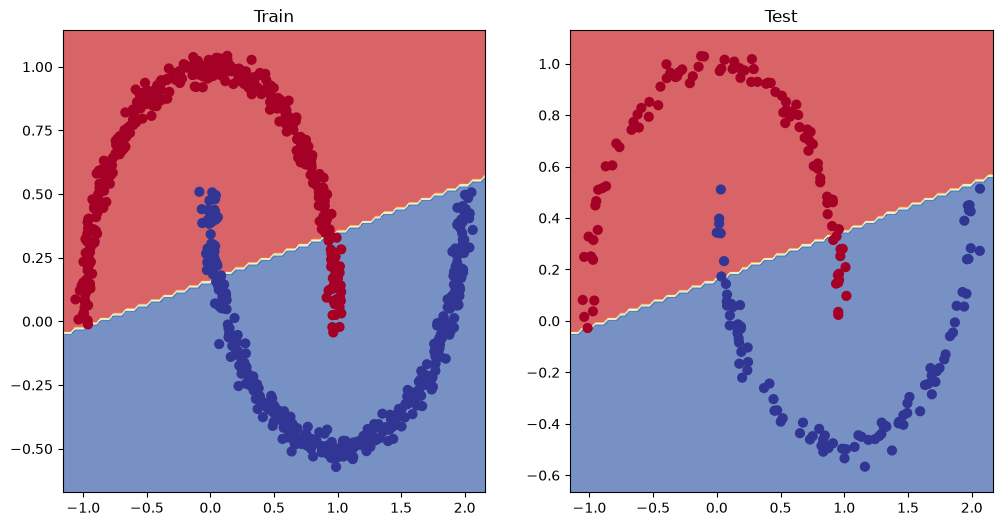

In [29]:

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
     

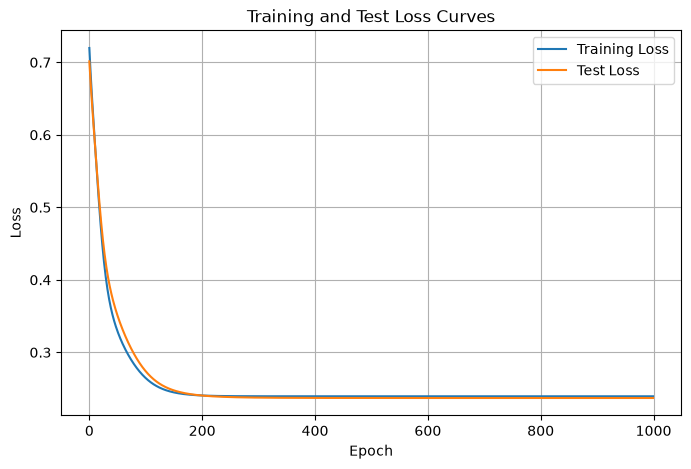

In [30]:
plot_loss_curves(train_losses, test_losses)

# Build a model with non-linear activation functions
To improve our model's ability to learn non-linear patterns, we can add a non-linear activation function, such as nn.ReLU() or nn.Sigmoid(), between the linear layers. Let's create ModelV2 with nn.ReLU().

In [31]:

# Build a model with non-linear activation functions
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.relu = nn.ReLU() # Our first non-linear activation function
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.relu_2 = nn.ReLU() # Our second non-linear activation function
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        # Pass the input through the layers and activation functions
        return self.layer_3(self.relu_2(self.layer_2(self.relu(self.layer_1(x)))))

# Instantiate ModelV2 and send it to the target device
model_2 = ModelV2().to(device)
model_2

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (relu): ReLU()
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (relu_2): ReLU()
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [32]:
# Reassign model, set epochs, loss function, and optimizer
model = model_2
epochs = 1000 # Keeping the same number of epochs for comparison

# Create a loss function (same as before)
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer (same as before)
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

print(f"Training {model.__class__.__name__} for {epochs} epochs...")

Training ModelV2 for 1000 epochs...


In [33]:

# Train and test the new model
train_losses_v2, acc_list_v2, test_losses_v2, test_acc_v2 = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

Epoch: 0 | Loss: 0.69013, Accuracy: 50.00% | Test loss: 0.68917, Test acc: 50.00%
Epoch: 10 | Loss: 0.67359, Accuracy: 50.00% | Test loss: 0.67418, Test acc: 50.00%
Epoch: 20 | Loss: 0.65313, Accuracy: 72.38% | Test loss: 0.65544, Test acc: 80.50%
Epoch: 30 | Loss: 0.62559, Accuracy: 84.00% | Test loss: 0.62986, Test acc: 79.00%
Epoch: 40 | Loss: 0.58975, Accuracy: 83.62% | Test loss: 0.59637, Test acc: 79.50%
Epoch: 50 | Loss: 0.54662, Accuracy: 84.38% | Test loss: 0.55579, Test acc: 80.00%
Epoch: 60 | Loss: 0.50038, Accuracy: 84.62% | Test loss: 0.51161, Test acc: 80.50%
Epoch: 70 | Loss: 0.45492, Accuracy: 85.38% | Test loss: 0.46746, Test acc: 81.00%
Epoch: 80 | Loss: 0.41557, Accuracy: 85.88% | Test loss: 0.42885, Test acc: 83.50%
Epoch: 90 | Loss: 0.38253, Accuracy: 86.12% | Test loss: 0.39606, Test acc: 85.00%
Epoch: 100 | Loss: 0.35444, Accuracy: 86.00% | Test loss: 0.36794, Test acc: 86.00%
Epoch: 110 | Loss: 0.33052, Accuracy: 86.50% | Test loss: 0.34356, Test acc: 87.00%
Epo

Text(0.5, 1.02, 'Decision Boundaries for ModelV2')

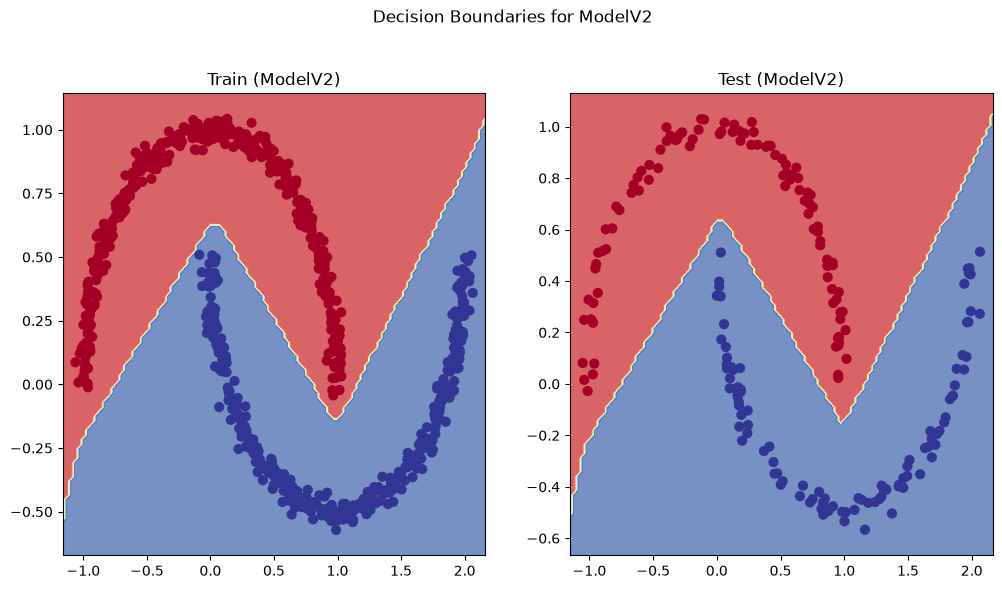

In [34]:

# Plot decision boundaries for training and test sets of ModelV2
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train (ModelV2)")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test (ModelV2)")
plot_decision_boundary(model, X_test, y_test)
plt.suptitle(f"Decision Boundaries for {model.__class__.__name__}", y=1.02)

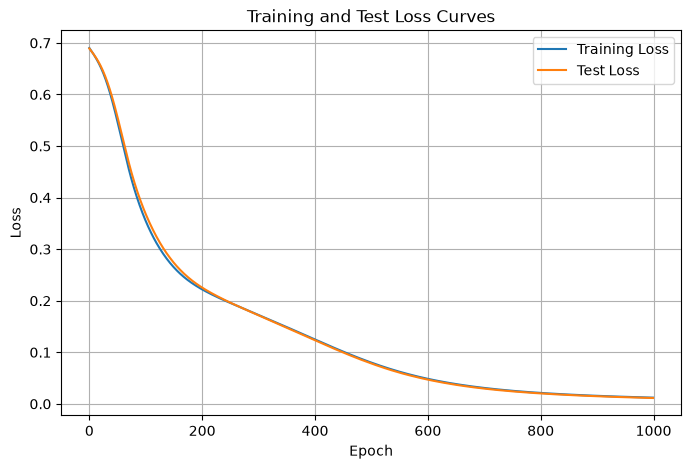

Text(0.5, 1.02, 'Loss Curves for ModelV2')

<Figure size 640x480 with 0 Axes>

In [36]:
# Plot loss curves for ModelV2
plot_loss_curves(train_losses_v2, test_losses_v2)
plt.suptitle(f"Loss Curves for {model.__class__.__name__}", y=1.02)

The LinearRegressionNN model is not suitable for the binary_classification_moons.csv dataset because the data is non-linear and cannot be separated by a straight decision boundary. ModelV0 showed moderate performance (around 86–89% accuracy) but remained limited due to the absence of non-linear activation functions. After increasing the network complexity and adding ReLU activation functions (ModelV2), the model successfully learned the non-linear patterns in the dataset and achieved 100% test accuracy. Therefore, ModelV2 is the most suitable architecture for the moons classification problem.